In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

import math

In [2]:
# path = '/kaggle/input/datasets/sehaj1104/student-mental-health-and-burnout-dataset/student_mental_health_burnout.csv'
path = '../data/raw/student_mental_health_burnout.csv'

# Load data & Exploring

In [3]:
df = pd.read_csv(path)
df.head()

,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,100001,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,High
1,100002,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,Low
2,100003,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,High
3,100004,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,High
4,100005,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,Low


In [4]:
df.info()
df = df.drop('student_id', axis=1)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   student_id               150000 non-null  int64  
 1   age                      150000 non-null  int64  
 2   gender                   150000 non-null  object 
 3   course                   150000 non-null  object 
 4   year                     150000 non-null  object 
 5   daily_study_hours        150000 non-null  float64
 6   daily_sleep_hours        150000 non-null  float64
 7   screen_time_hours        150000 non-null  float64
 8   stress_level             150000 non-null  object 
 9   anxiety_score            150000 non-null  int64  
 10  depression_score         150000 non-null  int64  
 11  academic_pressure_score  150000 non-null  int64  
 12  financial_stress_score   150000 non-null  int64  
 13  social_support_score     150000 non-null  int64  
 14  phys

In [5]:
df.describe(include='all')

,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
count,150000.000000,150000,150000,150000,150000.000000,150000.000000,150000.000000,150000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000,150000.000000,150000.000000,150000,150000
unique,NaN,3,6,4,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,3,3
top,NaN,Other,MBA,1st,NaN,NaN,NaN,High,NaN,NaN,NaN,NaN,NaN,NaN,Good,NaN,NaN,Average,Low
freq,NaN,50048,25231,37680,NaN,NaN,NaN,50295,NaN,NaN,NaN,NaN,NaN,NaN,50143,NaN,NaN,50138,50265
mean,21.000380,NaN,NaN,NaN,5.507869,6.499361,6.502819,NaN,5.493907,5.497360,5.507427,5.496027,5.516060,0.998115,NaN,75.009528,6.997389,NaN,NaN
std,2.581216,NaN,NaN,NaN,2.595592,1.443859,3.178948,NaN,2.872607,2.869022,2.875524,2.864698,2.870493,0.578866,NaN,14.409510,1.732180,NaN,NaN
min,17.000000,NaN,NaN,NaN,1.000000,4.000000,1.000000,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,NaN,50.000000,4.000000,NaN,NaN
25%,19.000000,NaN,NaN,NaN,3.300000,5.200000,3.700000,NaN,3.000000,3.000000,3.000000,3.000000,3.000000,0.500000,NaN,62.500000,5.500000,NaN,NaN
50%,21.000000,NaN,NaN,NaN,5.500000,6.500000,6.500000,NaN,5.000000,5.000000,6.000000,6.000000,6.000000,1.000000,NaN,75.000000,6.990000,NaN,NaN
75%,23.000000,NaN,NaN,NaN,7.700000,7.700000,9.300000,NaN,8.000000,8.000000,8.000000,8.000000,8.000000,1.500000,NaN,87.500000,8.500000,NaN,NaN


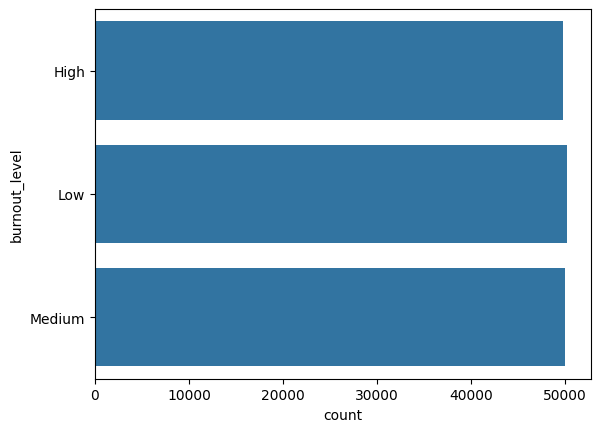

In [6]:
plt.figure()

sns.countplot(df['burnout_level'])
plt.show();

In [7]:
num_col = df.select_dtypes(exclude='object')
cat_col = df.select_dtypes(include='object')

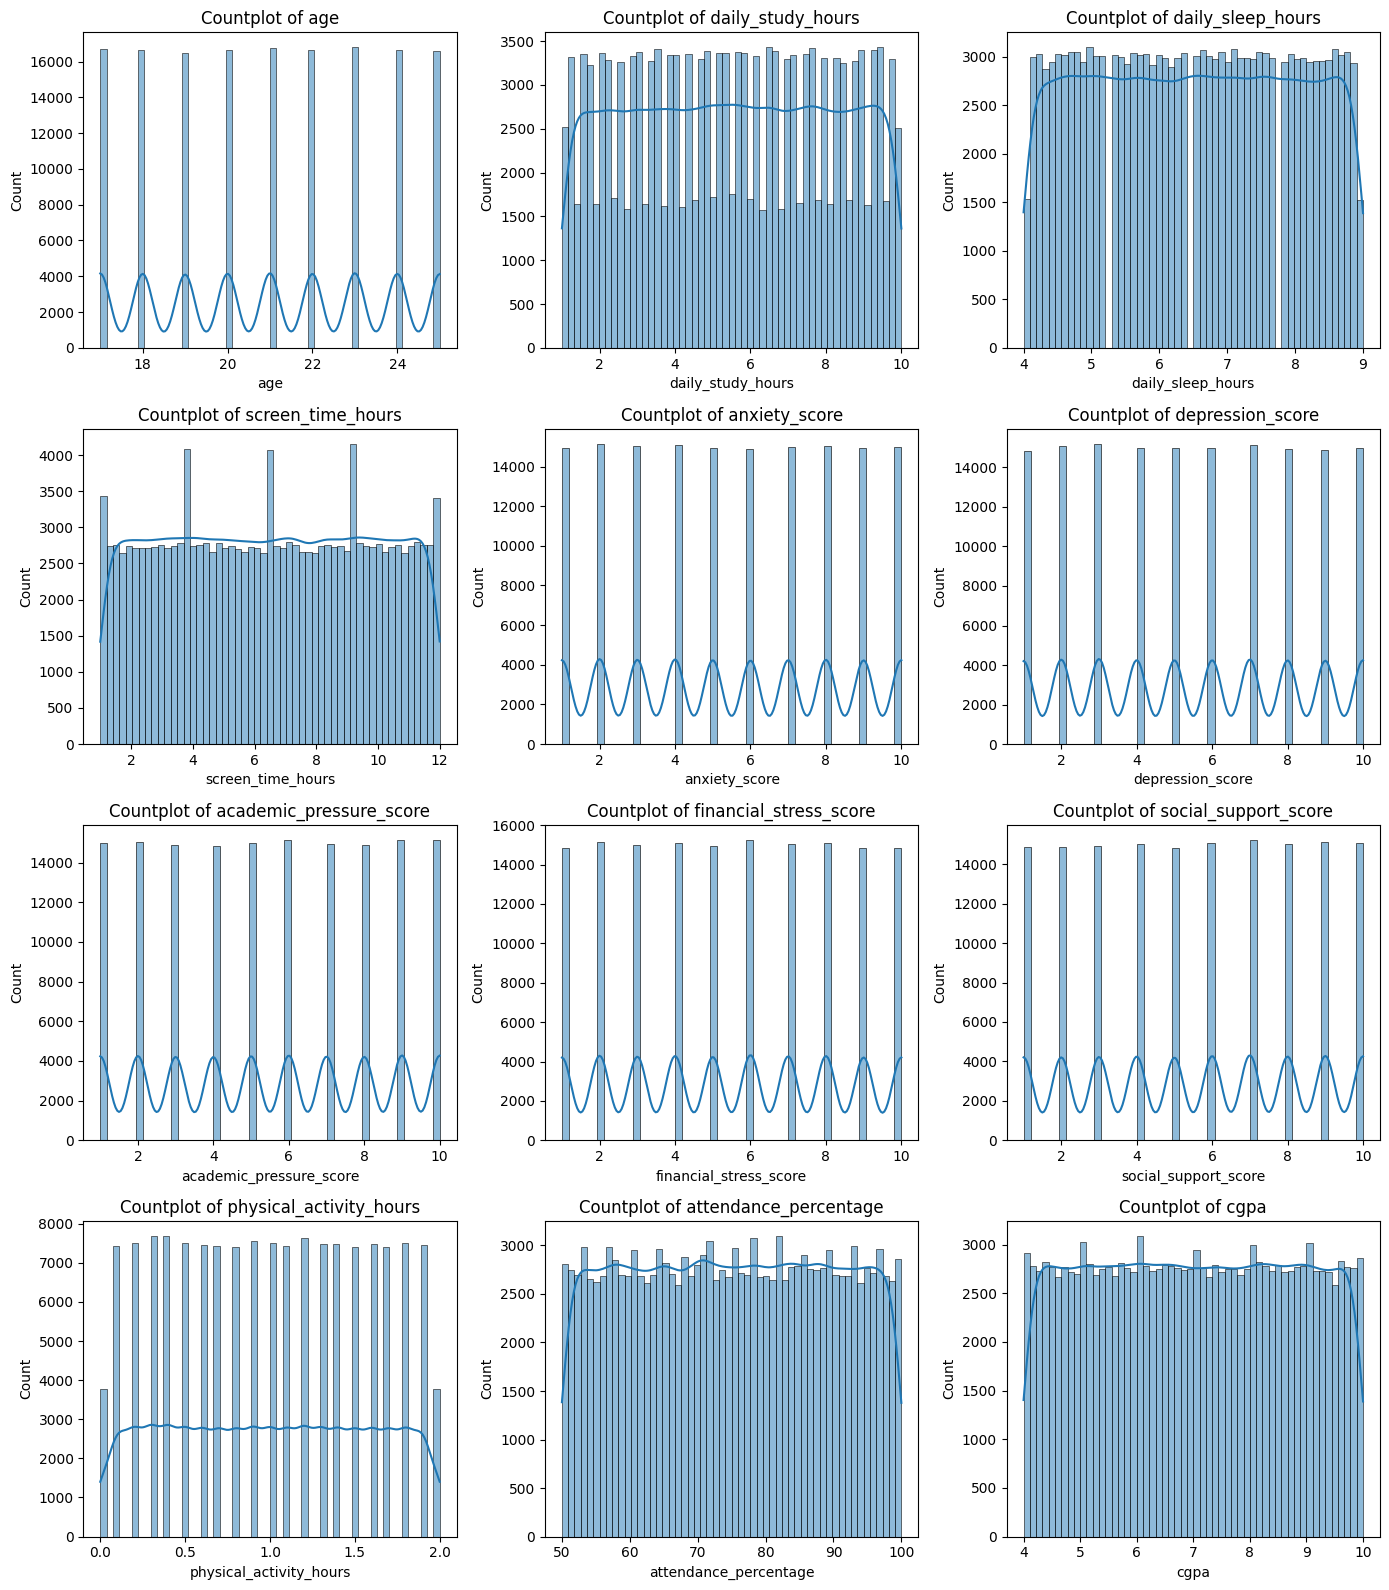

In [8]:
n_cols = len(num_col.columns)
no_row_plot = math.ceil(n_cols / 3)

fig, axes = plt.subplots(no_row_plot, 3, figsize=(14, no_row_plot * 4))
axes_flat = axes.flatten()

for i, col_name in enumerate(num_col.columns):
    sns.histplot(x=num_col[col_name], ax=axes_flat[i], kde=True)
    axes_flat[i].set_title(f'Countplot of {col_name}')

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis('off')

plt.tight_layout()
plt.show();

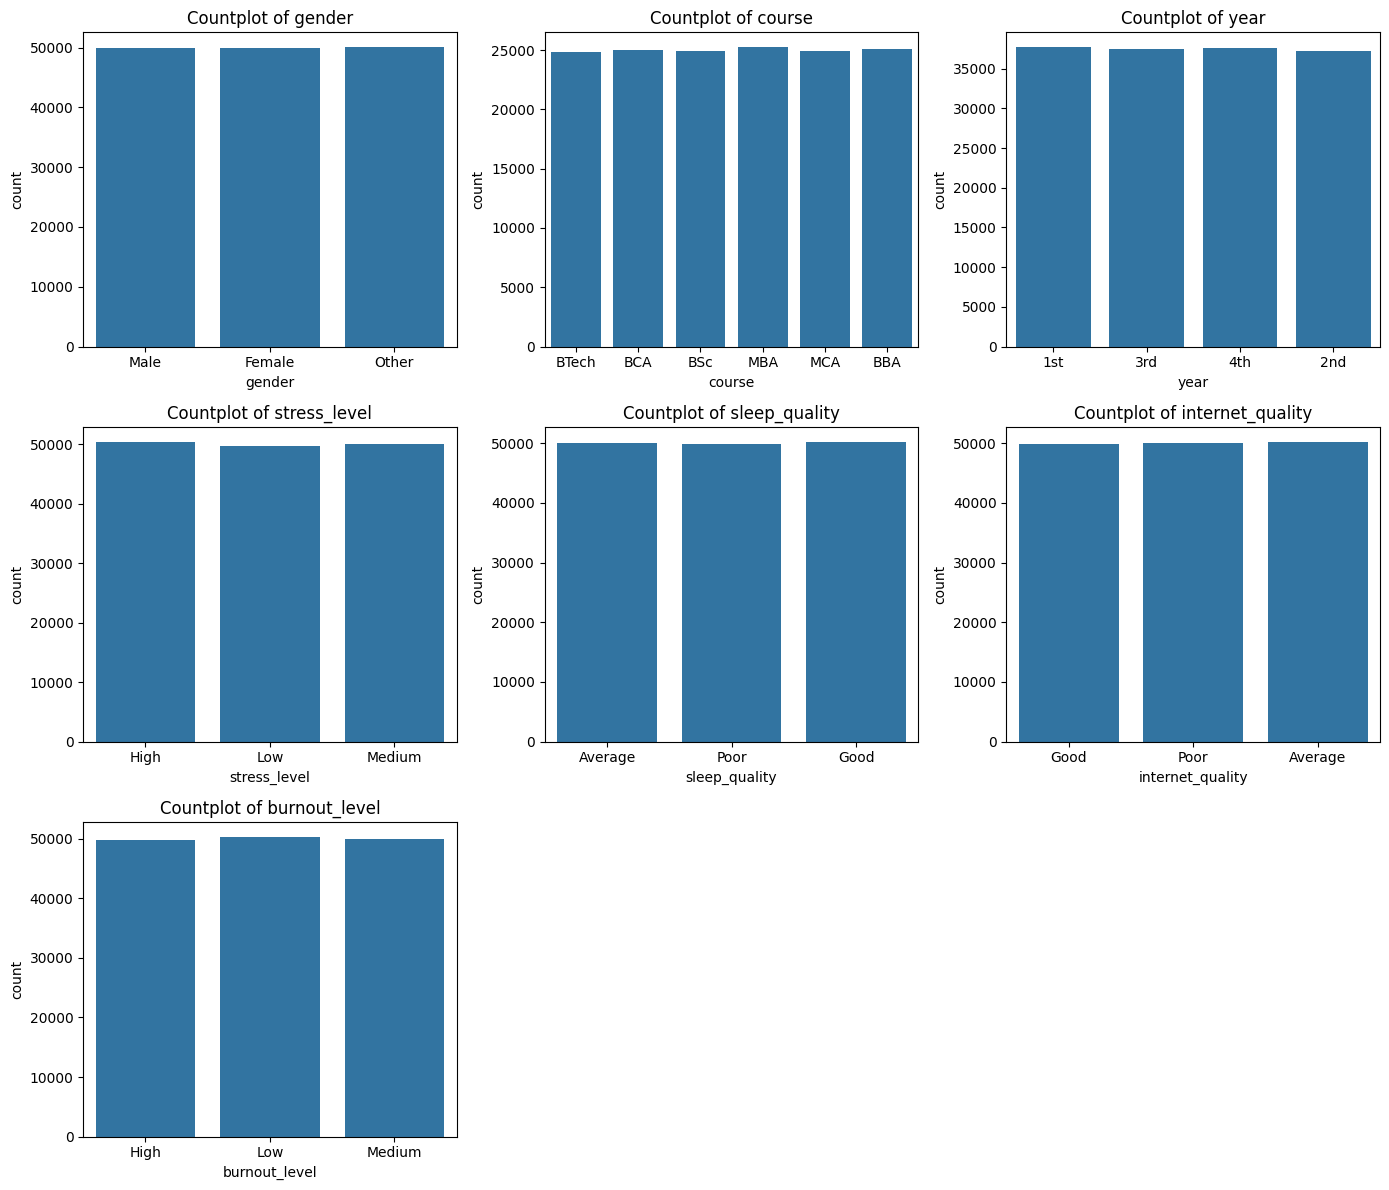

In [9]:
n_cols = len(cat_col.columns)
no_row_plot = math.ceil(n_cols / 3)

fig, axes = plt.subplots(no_row_plot, 3, figsize=(14, no_row_plot * 4))
axes_flat = axes.flatten()

for i, col_name in enumerate(cat_col.columns):
    sns.countplot(x=cat_col[col_name], ax=axes_flat[i])
    axes_flat[i].set_title(f'Countplot of {col_name}')

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis('off')

plt.tight_layout()
plt.show();

In [10]:
df = df.dropna()
df.isnull().sum()

age                        0
gender                     0
course                     0
year                       0
daily_study_hours          0
daily_sleep_hours          0
screen_time_hours          0
stress_level               0
anxiety_score              0
depression_score           0
academic_pressure_score    0
financial_stress_score     0
social_support_score       0
physical_activity_hours    0
sleep_quality              0
attendance_percentage      0
cgpa                       0
internet_quality           0
burnout_level              0
dtype: int64

In [11]:
# Onehot Encoding

nomial_col = ['course', 'gender']

df = pd.get_dummies(df, columns=nomial_col, drop_first=True)
df.head()

,age,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,...,cgpa,internet_quality,burnout_level,course_BCA,course_BSc,course_BTech,course_MBA,course_MCA,gender_Male,gender_Other
0,23,1st,4.3,6.8,6.1,High,10,3,4,2,...,9.63,Good,High,False,False,True,False,False,True,False
1,20,3rd,1.4,4.7,3.0,High,2,10,8,5,...,6.04,Poor,Low,False,False,True,False,False,True,False
2,24,4th,3.7,4.8,1.5,Low,2,7,8,6,...,8.31,Good,High,True,False,False,False,False,False,False
3,21,4th,1.6,6.7,7.0,High,3,3,4,9,...,5.95,Good,High,False,True,False,False,False,True,False
4,23,4th,2.0,6.7,5.4,High,7,7,6,4,...,8.51,Good,Low,False,True,False,False,False,False,True


In [12]:
bool_col = df.select_dtypes(include='bool').columns
df[bool_col] = df[bool_col].astype('int')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 24 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   age                      150000 non-null  int64  
 1   year                     150000 non-null  object 
 2   daily_study_hours        150000 non-null  float64
 3   daily_sleep_hours        150000 non-null  float64
 4   screen_time_hours        150000 non-null  float64
 5   stress_level             150000 non-null  object 
 6   anxiety_score            150000 non-null  int64  
 7   depression_score         150000 non-null  int64  
 8   academic_pressure_score  150000 non-null  int64  
 9   financial_stress_score   150000 non-null  int64  
 10  social_support_score     150000 non-null  int64  
 11  physical_activity_hours  150000 non-null  float64
 12  sleep_quality            150000 non-null  object 
 13  attendance_percentage    150000 non-null  float64
 14  cgpa

In [13]:
# Label Encoding

ordinal_col = ['year', 'stress_level', 'sleep_quality', 'internet_quality', 'burnout_level']

df[ordinal_col] = df[ordinal_col].replace({    
    '1st': 1, '2nd': 2, '3rd': 3, '4th': 4,
    'Low': 0, 'Medium': 1, 'High': 2,
    'Poor': 0, 'Average': 1, 'Good': 2
})

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 24 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   age                      150000 non-null  int64  
 1   year                     150000 non-null  int64  
 2   daily_study_hours        150000 non-null  float64
 3   daily_sleep_hours        150000 non-null  float64
 4   screen_time_hours        150000 non-null  float64
 5   stress_level             150000 non-null  int64  
 6   anxiety_score            150000 non-null  int64  
 7   depression_score         150000 non-null  int64  
 8   academic_pressure_score  150000 non-null  int64  
 9   financial_stress_score   150000 non-null  int64  
 10  social_support_score     150000 non-null  int64  
 11  physical_activity_hours  150000 non-null  float64
 12  sleep_quality            150000 non-null  int64  
 13  attendance_percentage    150000 non-null  float64
 14  cgpa

<Axes: >

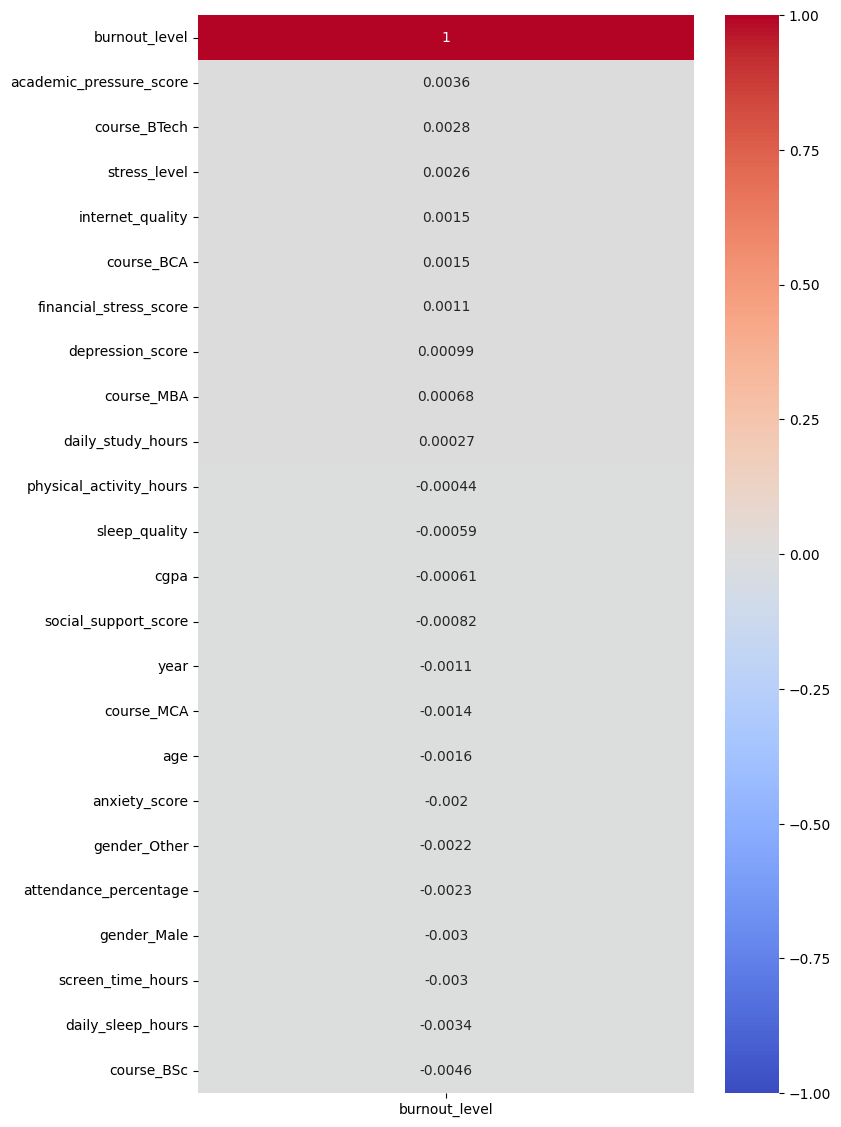

In [14]:
plt.figure(figsize=(8, 14))

sns.heatmap(
    df.corr(method='pearson', numeric_only=True)[['burnout_level']].sort_values(by='burnout_level', ascending=False),
    annot=True,
    cmap='coolwarm',
    vmin=-1, vmax=1
)

## Kiểm tra đa cộng tuyến trên tập dữ liệu đã được xử lý (chỉ số VIF)

In [15]:
df = df.drop('gender_Other', axis=1)
X = df.drop('burnout_level', axis=1)
X.head()

,age,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,...,sleep_quality,attendance_percentage,cgpa,internet_quality,course_BCA,course_BSc,course_BTech,course_MBA,course_MCA,gender_Male
0,23,1,4.3,6.8,6.1,2,10,3,4,2,...,1,66.5,9.63,2,0,0,1,0,0,1
1,20,3,1.4,4.7,3.0,2,2,10,8,5,...,0,55.8,6.04,0,0,0,1,0,0,1
2,24,4,3.7,4.8,1.5,0,2,7,8,6,...,2,85.0,8.31,2,1,0,0,0,0,0
3,21,4,1.6,6.7,7.0,2,3,3,4,9,...,0,89.1,5.95,2,0,1,0,0,0,1
4,23,4,2.0,6.7,5.4,2,7,7,6,4,...,2,58.7,8.51,2,0,1,0,0,0,0


In [19]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = X.dropna()
y = df['burnout_level'].copy()

pd.DataFrame(
    {
        'Feature': X.columns,
        'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    }
).sort_values(by='VIF', ascending=False)

,Feature,VIF
0,age,41.868024
13,attendance_percentage,23.713942
3,daily_sleep_hours,18.813669
14,cgpa,15.684100
1,year,5.806885
2,daily_study_hours,5.359059
4,screen_time_hours,5.065498
10,social_support_score,4.589762
9,financial_stress_score,4.588030
7,depression_score,4.571918


# Training model (Random Forest, LightGBM, XGBoost)

In [23]:
import pandas as pd
import numpy as np
import time

from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

import lightgbm as lgb
import xgboost as xgb


def evaluate_models_cv(X, y, n_splits=5, random_state=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    models = {
        "RandomForest": RandomForestClassifier(random_state=42),
        "LightGBM": lgb.LGBMClassifier(random_state=42),
        "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
    }

    results = []

    for model_name, model in models.items():
        f1s, recs, precs = [], [], []
        train_times, pred_times = [], []

        for train_idx, test_idx in skf.split(X, y):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            # Train
            start_train = time.time()
            model.fit(X_train, y_train)
            train_times.append(time.time() - start_train)

            # Predict
            start_pred = time.time()
            preds = model.predict(X_test)
            pred_times.append(time.time() - start_pred)

            # Metrics
            precs.append(precision_score(y_test, preds, average='weighted'))
            recs.append(recall_score(y_test, preds, average='weighted'))
            f1s.append(f1_score(y_test, preds, average='weighted'))

        results.append({
            "Model": model_name,
            "Precision": np.mean(precs),
            "Recall": np.mean(recs),
            "F1": np.mean(f1s),
            "Train time": np.mean(train_times),
            "Predict time": np.mean(pred_times)
        })

    return pd.DataFrame(results), models

In [24]:
df_eval, models = evaluate_models_cv(X, y)

MemoryError: could not allocate 8388608 bytes

In [ ]:
df_eval

,Model,Precision,Recall,F1,Train time,Predict time
0,RandomForest,0.335447,0.335547,0.335091,40.652738,1.417300
1,LightGBM,0.334023,0.334173,0.333197,2.127330,0.209619
2,XGBoost,0.332940,0.332967,0.332883,2.777341,0.121489


In [ ]:
N_RUNS = 50
SUBSET_SIZE = 0.5  

records = []

for i in range(N_RUNS):
    X_sub, _, y_sub, _ = train_test_split(
        X_test, y_test,
        test_size=1 - SUBSET_SIZE,
        random_state=i,
        stratify=y_test
    )

    rec_lgb  = recall_score(y_sub, models['LightGBM'].predict(X_sub), average='weighted')
    rec_xgb = recall_score(y_sub, models['XGBoost'].predict(X_sub), average='weighted')

    records.append({
        'run'         : i + 1,
        'LightGBM' : round(rec_lgb,  6),
        'XGB': round(rec_xgb, 6),
    })


recall_df = pd.DataFrame(records)
recall_df.head()

,run,LightGBM,XGB_Accuracy
0,1,0.473733,0.545800
1,2,0.468867,0.544667
2,3,0.472533,0.542333
3,4,0.474400,0.542200
4,5,0.472067,0.547267


### Áp dụng kiểm định để so sánh 2 mô hình

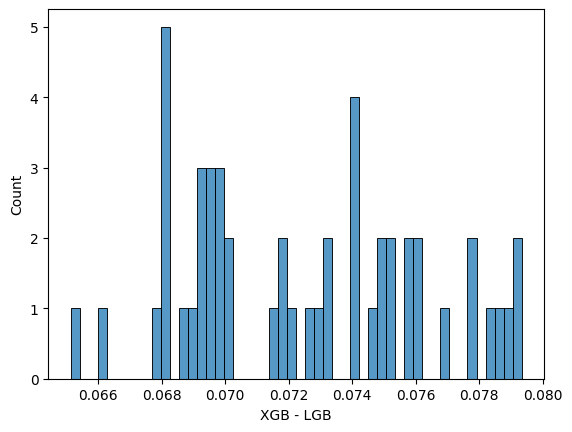

In [ ]:
recall_df['XGB - LGB'] = recall_df['XGB_Accuracy'] - recall_df['LightGBM']

sns.histplot(recall_df['XGB - LGB'], bins=50)
plt.show();

Đặt ra giả thuyết: "Accuracy của mô hình XGBoost là lớn hơn LightGBM"

Gọi hiệu số giữa Accuracy của XGBoost và LightGBM là d, cặp giả thuyết thống kê là:
H0:μd=0H_0: \mu_d = 0
H1:μd>0H_1: \mu_d > 0
Chọn mức ý nghĩa là $\alpha = 0.05$. Thực hiện kiểm định giả thuyết trên

In [ ]:
from scipy import stats

t_stat, p_val = stats.ttest_1samp(recall_df['XGB - LGB'], 0)
alpha = 0.05
print(f'T statistic: {t_stat}\np-value: {p_val}')

print(f'Bác bỏ H0 vì p-value < alpha ({p_val} < {alpha})' if p_val < alpha else f'Không bác bỏ H0 vì p-value >= alpha ({p_val} > {alpha})')

T statistic: 135.40162953950062
p-value: 9.705467973563513e-65
Bác bỏ H0 vì p-value < alpha (9.705467973563513e-65 < 0.05)


# Hyperparameter Fine-tuning

In [ ]:
import optuna
from xgboost.callback import EarlyStopping

from xgboost.callback import EarlyStopping

def objective(trial):
    param = {
        "objective": "multi:softprob",
        "num_class": 3,
        "eval_metric": "mlogloss",
        "random_state": 42,

        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.1, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),

        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.4, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),

        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }

    X_train_sub, X_val, y_train_sub, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train
    )

    model = xgb.XGBClassifier(**param)

    model.fit(
        X_train_sub, y_train_sub,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    preds = model.predict(X_val)

    score = recall_score(y_val, preds, average='weighted') 

    return score

In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

print("Best Parameters:", study.best_params)

[I 2026-04-06 16:04:45,686] A new study created in memory with name: no-name-4fc4933e-cbaa-4e8c-82fd-d914d4e8c33f
[I 2026-04-06 16:05:06,678] Trial 0 finished with value: 0.3348333333333333 and parameters: {'max_depth': 10, 'learning_rate': 0.006231367280480965, 'n_estimators': 450, 'min_child_weight': 9, 'subsample': 0.4173322280123948, 'colsample_bytree': 0.5551332127113806, 'reg_alpha': 0.0016685396580176537, 'reg_lambda': 0.008331063262155219}. Best is trial 0 with value: 0.3348333333333333.
[I 2026-04-06 16:05:11,199] Trial 1 finished with value: 0.3324166666666667 and parameters: {'max_depth': 7, 'learning_rate': 0.0028352644466439225, 'n_estimators': 128, 'min_child_weight': 2, 'subsample': 0.5938111884106586, 'colsample_bytree': 0.7608448080460525, 'reg_alpha': 0.12750810803859536, 'reg_lambda': 0.17823189763624495}. Best is trial 0 with value: 0.3348333333333333.
[I 2026-04-06 16:05:29,609] Trial 2 finished with value: 0.33108333333333334 and parameters: {'max_depth': 10, 'lea

Best Parameters: {'max_depth': 14, 'learning_rate': 0.003073231294889544, 'n_estimators': 714, 'min_child_weight': 8, 'subsample': 0.4377561367751813, 'colsample_bytree': 0.6784975015396258, 'reg_alpha': 0.1056678076132909, 'reg_lambda': 0.8867716569424934}


In [ ]:
optuna.visualization.plot_optimization_history(study).show()

In [ ]:
optuna.visualization.plot_param_importances(study).show()